In [22]:
# Cell 1: Imports & Data Load
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Telco-Customer-Churn.csv")

print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nFirst 3 rows:")
df.head(3)

Shape: (7043, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

First 3 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [23]:
# Cell 2: Data Quality Check
print("=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== TARGET DISTRIBUTION ===")
print(df['Churn'].value_counts())
print(f"\nChurn Rate: {df['Churn'].value_counts(normalize=True)['Yes']:.1%}")

=== DATA TYPES ===
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

=== MISSING VALUES ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
Pap

In [24]:
# Cell 3: Data CLeaning

# Fix 1: TotalCharges has hidden spaces - convert to numeric, blank become NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fix 2: Drop the 11 rows where TotalCharges is non NaN (brand new customers, tenure=0)
print(f"Rows before drop: {df.shape[0]}")
df = df.dropna(subset=['TotalCharges'])
print(f"Rows after drop: {df.shape[0]}")

# Fix 3: Collapse "No internet service" and "No phone service" -> just "No"
# These columns all mean the same thing: the customer doesn't have the add-on
no_service_cols = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]
for col in no_service_cols:
    df[col] = df[col].replace({'No internet service': 'No', 'No phone service': 'No'})

# Fix 4: Convert Churn to binary 1/0 (models need numbers, not "Yes"/"No")
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Fix 5: Drop customerID (not useful for modeling)
# df = df.drop(columns=['customerID'])

print(f"\nChurn distribution after encoding:")
print(df['Churn'].value_counts())
print(f"\nTotalCharges dtype note: {df['TotalCharges'].dtype}")
print(f"\nFinal shape {df.shape}")

Rows before drop: 7043
Rows after drop: 7032

Churn distribution after encoding:
Churn
0    5163
1    1869
Name: count, dtype: int64

TotalCharges dtype note: float64

Final shape (7032, 21)


C:\Users\I847229\AppData\Local\Temp\ipykernel_49068\3822472023.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,0].boxplot([df[df['Churn']==0]['MonthlyCharges'], df[df['Churn']==1]['MonthlyCharges']],


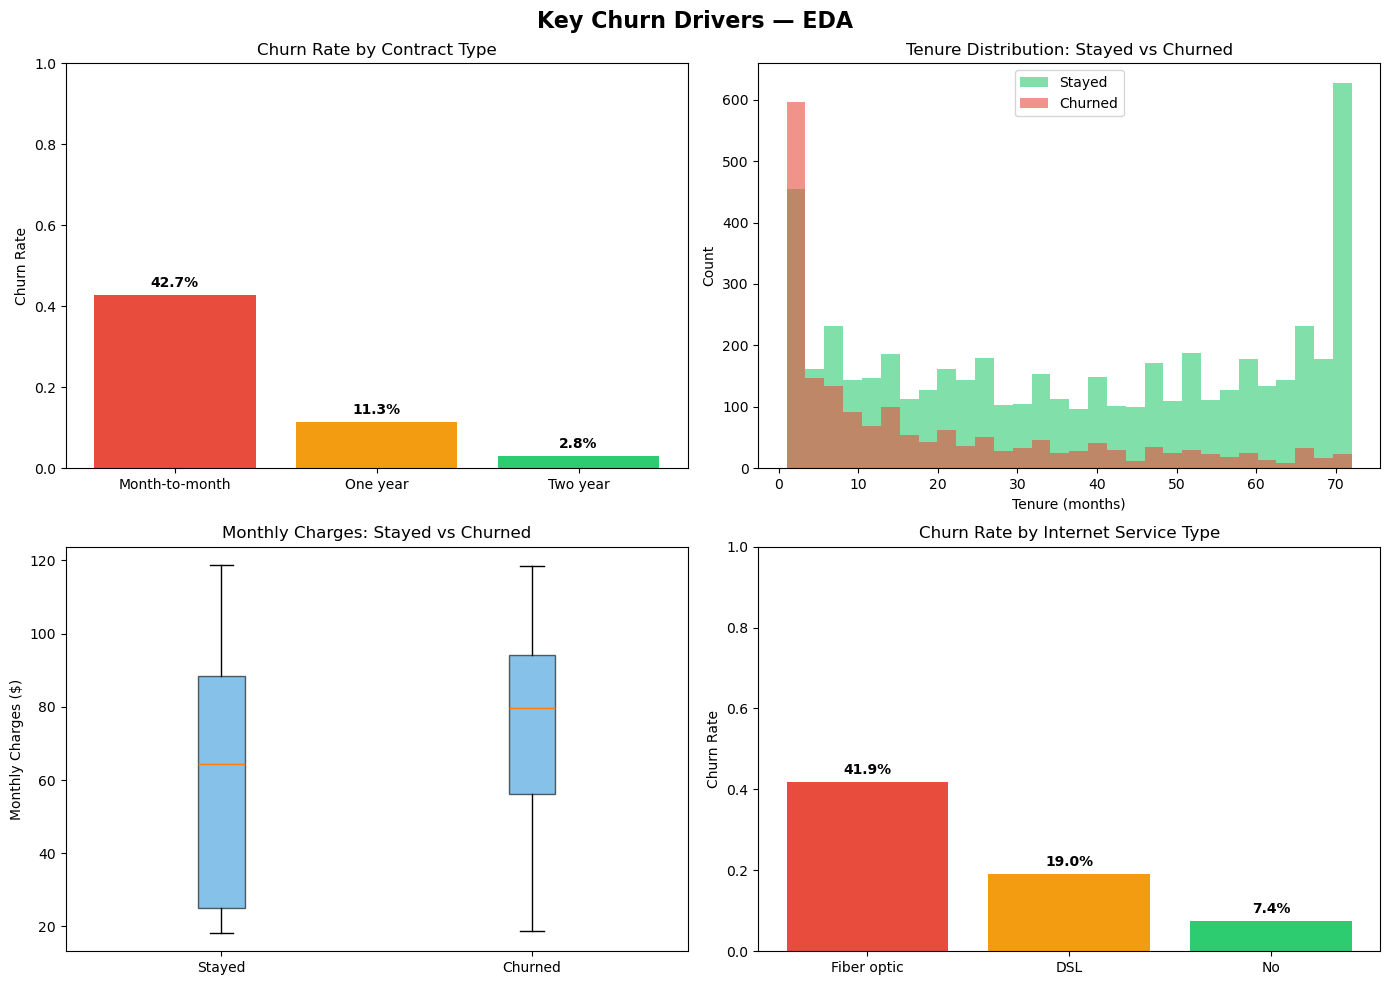

In [25]:
# Cell 4: EDA Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Key Churn Drivers — EDA', fontsize=16, fontweight='bold')

# Plot 1: Churn by Contract Type
contract_churn = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False)
axes[0,0].bar(contract_churn.index, contract_churn.values, color=['#e74c3c','#f39c12','#2ecc71'])
axes[0,0].set_title('Churn Rate by Contract Type')
axes[0,0].set_ylabel('Churn Rate')
axes[0,0].set_ylim(0, 1)
for i, v in enumerate(contract_churn.values):
    axes[0,0].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

# Plot 2: Tenure distribution by churn
axes[0,1].hist(df[df['Churn']==0]['tenure'], bins=30, alpha=0.6, label='Stayed', color='#2ecc71')
axes[0,1].hist(df[df['Churn']==1]['tenure'], bins=30, alpha=0.6, label='Churned', color='#e74c3c')
axes[0,1].set_title('Tenure Distribution: Stayed vs Churned')
axes[0,1].set_xlabel('Tenure (months)')
axes[0,1].set_ylabel('Count')
axes[0,1].legend()

# Plot 3: Monthly Charges by churn
axes[1,0].boxplot([df[df['Churn']==0]['MonthlyCharges'], df[df['Churn']==1]['MonthlyCharges']],
                   labels=['Stayed', 'Churned'], patch_artist=True,
                   boxprops=dict(facecolor='#3498db', alpha=0.6))
axes[1,0].set_title('Monthly Charges: Stayed vs Churned')
axes[1,0].set_ylabel('Monthly Charges ($)')

# Plot 4: Churn rate by Internet Service
internet_churn = df.groupby('InternetService')['Churn'].mean().sort_values(ascending=False)
axes[1,1].bar(internet_churn.index, internet_churn.values, color=['#e74c3c','#f39c12','#2ecc71'])
axes[1,1].set_title('Churn Rate by Internet Service Type')
axes[1,1].set_ylabel('Churn Rate')
axes[1,1].set_ylim(0, 1)
for i, v in enumerate(internet_churn.values):
    axes[1,1].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [26]:
# Cell 5: Feature Engineering & Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Step 1: Encode all remaining text columns as numbers
# Binary columns (Yes/No) → 1/0
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV',
               'StreamingMovies', 'PaperlessBilling']

for col in binary_cols:
    df[col] = (df[col] == 'Yes').astype(int)

# Step 2: Multi-value categoricals → one-hot encoding
# Contract: Month-to-month / One year / Two year
# InternetService: Fiber optic / DSL / No
# PaymentMethod: 4 options
df = pd.get_dummies(df, columns=['Contract', 'InternetService', 'PaymentMethod'], drop_first=False)

# Step 3: Separate features (X) from target (y)
# Safety drop — remove ID column if still present
df = df.drop(columns=['customerID'], errors='ignore')
X = df.drop(columns=['Churn'])
y = df['Churn']

print(f"Features shape: {X.shape}")
print(f"Feature names:\n{X.columns.tolist()}")

# Step 4: Train/test split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nChurn rate in train: {y_train.mean():.1%}")
print(f"Churn rate in test: {y_test.mean():.1%}")


Features shape: (7032, 26)
Feature names:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']

Training set: (5625, 26)
Test set: (1407, 26)

Churn rate in train: 26.6%
Churn rate in test: 26.6%


In [27]:
# Cell 6: Scale features + Train 3 models
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score)

# Scale features - fit ONLY on training data, then apply to both
# "Fit on train only" rule: if we fit on all data, we leak test info into training
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define all 3 models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0)
}

# Train and evaluate each model
results = {}
for name, model, in models.items():
    # Logistic Regression uses scaled data, tree models use raw
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob)
    }

# Print results table
results_df = pd.DataFrame(results).T
print(results_df.round(3).to_string())

                     accuracy  precision  recall     f1  roc_auc
Logistic Regression     0.805      0.649   0.578  0.611    0.836
Random Forest           0.785      0.615   0.508  0.556    0.818
XGBoost                 0.772      0.577   0.532  0.554    0.807


Running grid search... (this will take 1-2 minutes)
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Done in 13 seconds

Best parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}
Best CV AUC-ROC: 0.8477

=== TUNED XGBoost vs Original Results ===
Metric         Original      Tuned     Change
---------------------------------------------
Accuracy          0.772      0.793 ↑   0.021
Precision         0.577      0.630 ↑   0.053
Recall            0.532      0.537 ↑   0.005
F1                0.554      0.580 ↑   0.026
AUC-ROC           0.807      0.840 ↑   0.033


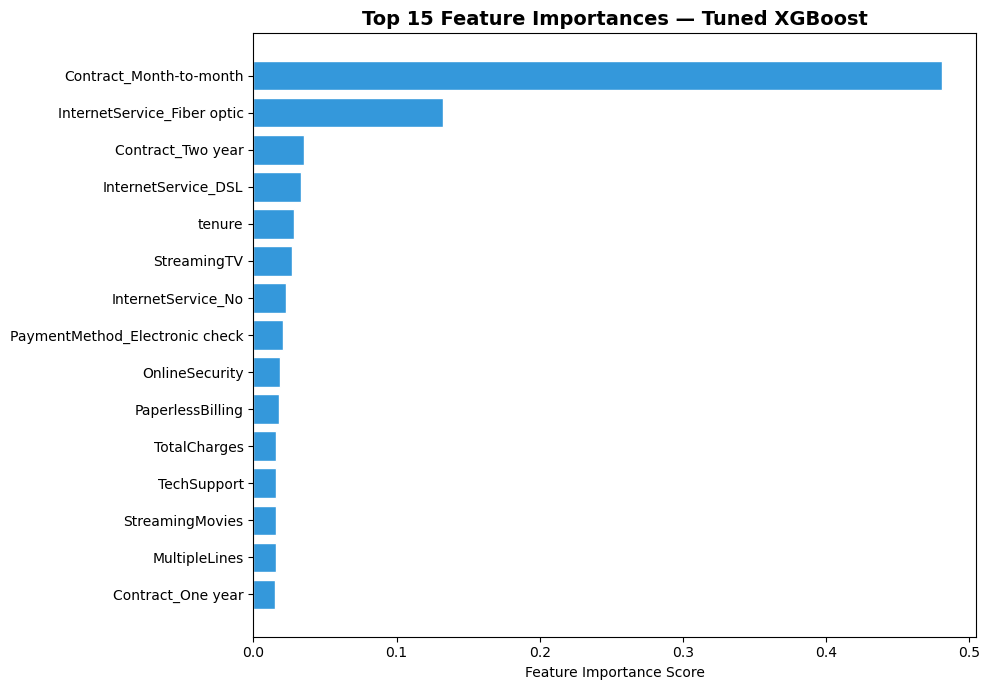


Top 10 features ranked:
   1. Contract_Month-to-month                  0.4806
   2. InternetService_Fiber optic              0.1327
   3. Contract_Two year                        0.0354
   4. InternetService_DSL                      0.0333
   5. tenure                                   0.0284
   6. StreamingTV                              0.0267
   7. InternetService_No                       0.0231
   8. PaymentMethod_Electronic check           0.0209
   9. OnlineSecurity                           0.0184
  10. PaperlessBilling                         0.0179


In [28]:
# Cell 7: Hyperparameter Tuning + Feature Importance
from sklearn.model_selection import GridSearchCV
import time

# --- PART A: Tune XGBoost ---
param_grid = {
    'n_estimators':  [100, 200, 300],
    'max_depth':     [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample':     [0.8, 1.0]
}

xgb_base = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0)

grid_search = GridSearchCV(
    estimator  = xgb_base,
    param_grid = param_grid,
    cv         = 5,              # 5-fold cross validation
    scoring    = 'roc_auc',      # optimize for AUC-ROC
    n_jobs     = -1,             # use all CPU cores
    verbose    = 1
)

print("Running grid search... (this will take 1-2 minutes)")
start = time.time()
grid_search.fit(X_train, y_train)
elapsed = time.time() - start
print(f"Done in {elapsed:.0f} seconds")

# Best params and score
print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV AUC-ROC: {grid_search.best_score_:.4f}")

# Evaluate tuned model on held-out test set
best_xgb = grid_search.best_estimator_
y_pred_tuned = best_xgb.predict(X_test)
y_prob_tuned = best_xgb.predict_proba(X_test)[:, 1]

print(f"\n=== TUNED XGBoost vs Original Results ===")
print(f"{'Metric':<12} {'Original':>10} {'Tuned':>10} {'Change':>10}")
print("-" * 45)
metrics = {
    'Accuracy':  accuracy_score(y_test, y_pred_tuned),
    'Precision': precision_score(y_test, y_pred_tuned),
    'Recall':    recall_score(y_test, y_pred_tuned),
    'F1':        f1_score(y_test, y_pred_tuned),
    'AUC-ROC':   roc_auc_score(y_test, y_prob_tuned)
}
original = {'Accuracy': 0.772, 'Precision': 0.577, 'Recall': 0.532, 'F1': 0.554, 'AUC-ROC': 0.807}
for metric, value in metrics.items():
    change = value - original[metric]
    arrow = "↑" if change > 0 else "↓"
    print(f"{metric:<12} {original[metric]:>10.3f} {value:>10.3f} {arrow}{abs(change):>8.3f}")

# --- PART B: Feature Importance ---
feature_names = X_train.columns.tolist()
importances = best_xgb.feature_importances_

# Sort by importance
indices = importances.argsort()[::-1]
top_n = 15

plt.figure(figsize=(10, 7))
plt.title('Top 15 Feature Importances — Tuned XGBoost', fontsize=14, fontweight='bold')
bars = plt.barh(
    range(top_n),
    importances[indices[:top_n]][::-1],
    color='#3498db',
    edgecolor='white'
)
plt.yticks(range(top_n), [feature_names[i] for i in indices[:top_n]][::-1])
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 10 features ranked:")
for rank, idx in enumerate(indices[:10], 1):
    print(f"  {rank:>2}. {feature_names[idx]:<40} {importances[idx]:.4f}")

In [29]:
# Cell 8: Export model and scaler for API deployment
import joblib
import json
import os

# Create models directory
os.makedirs('models', exist_ok=True)

# Save the tuned XGBoost model
joblib.dump(best_xgb, 'models/propensity_model.pkl')

# Save the scaler (must use same scaler in production)
joblib.dump(scaler, 'models/scaler.pkl')

# Save feature names — API needs to know column order
feature_config = {
    'feature_names': X_train.columns.tolist(),
    'model_version': '1.0',
    'auc_roc': 0.840,
    'top_features': ['Contract_Month-to-month', 'InternetService_Fiber optic', 
                     'Contract_Two year', 'tenure', 'StreamingTV']
}
with open('models/feature_config.json', 'w') as f:
    json.dump(feature_config, f, indent=2)

# Verify files saved
for f in os.listdir('models'):
    size = os.path.getsize(f'models/{f}')
    print(f"  ✓ models/{f}  ({size:,} bytes)")

print("\nModel export complete. Ready for API deployment.")

# Quick sanity check — reload and predict one row
model_check = joblib.load('models/propensity_model.pkl')
sample = X_test.iloc[[0]]
prob = model_check.predict_proba(sample)[0][1]
print(f"\nSanity check — sample prediction: {prob:.1%} churn probability")

  ✓ models/feature_config.json  (907 bytes)
  ✓ models/propensity_model.pkl  (171,418 bytes)
  ✓ models/scaler.pkl  (2,007 bytes)

Model export complete. Ready for API deployment.

Sanity check — sample prediction: 2.2% churn probability
